In [ ]:
# =========================
# URL + EMAIL PHISHING DETECTION
# 70 / 10 / 20 SPLIT
# MULTI-MODEL + BEST SELECTION
# =========================
!pip -q install scikit-learn joblib matplotlib pandas numpy

import os, random, math
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

# -----------------------------
# CONFIG
# -----------------------------
SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.10
TEST_RATIO  = 0.20

random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# HELPERS
# -----------------------------
def split_70_10_20(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        random_state=SEED,
        stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=2/3,
        random_state=SEED,
        stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def safe_logloss(y_true, model, X):
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X)
        p = np.clip(p, 1e-9, 1.0)
        return log_loss(y_true, p)
    return float("nan")

def plot_bar(df, title, fname):
    plt.figure(figsize=(10,4))
    plt.bar(df["model"], df["val_accuracy"])
    plt.xticks(rotation=18, ha="right")
    plt.ylim(0,1)
    plt.title(title)
    plt.ylabel("Validation Accuracy")
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.close()
    print("Saved plot:", fname)

# -----------------------------
# URL FEATURE EXTRACTION
# -----------------------------
def extract_url_features(url):
    url = str(url)
    u = url.lower()
    return {
        "length": len(url),
        "digits": sum(c.isdigit() for c in url),
        "special": sum(not c.isalnum() for c in url),
        "dots": url.count("."),
        "slashes": url.count("/"),
        "https": int(u.startswith("https")),
        "http": int(u.startswith("http")),
        "login": int("login" in u),
        "verify": int("verify" in u),
        "bank": int("bank" in u),
        "secure": int("secure" in u),
        "password": int("password" in u),
    }

# =========================
# 1) URL PHISHING MODELS
# =========================
print("\n==== URL PHISHING TRAINING ====")

urls = pd.read_csv("C:\Users\Deepa\Downloads\phising_detec\backend\data\emails_1m.csv").dropna()
X_url = pd.DataFrame(urls["url"].apply(extract_url_features).tolist())
y_url = urls["label"].astype(int).values

Xtr, Xva, Xte, ytr, yva, yte = split_70_10_20(X_url, y_url)

url_models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "SGD_LogLoss": SGDClassifier(loss="log_loss", max_iter=3000),
    "RandomForest": RandomForestClassifier(n_estimators=300),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300),
    "GradientBoosting": GradientBoostingClassifier()
}

url_results = []
best_url = None

for name, model in url_models.items():
    model.fit(Xtr, ytr)
    acc = accuracy_score(yva, model.predict(Xva))
    ll  = safe_logloss(yva, model, Xva)
    url_results.append({"model": name, "val_accuracy": acc, "val_logloss": ll})
    
url_df = pd.DataFrame(url_results).sort_values(
    ["val_accuracy","val_logloss"], ascending=[False,True]
)
print(url_df)

best_url_name = url_df.iloc[0]["model"]
best_url_model = url_models[best_url_name]

print("BEST URL MODEL:", best_url_name)
print("URL TEST ACC:", accuracy_score(yte, best_url_model.predict(Xte)))

joblib.dump(best_url_model, "best_url_model.joblib")
plot_bar(url_df, "URL Models Validation Accuracy", "url_models_accuracy.png")

# =========================
# 2) EMAIL PHISHING MODELS
# =========================
print("\n==== EMAIL PHISHING TRAINING ====")

emails = pd.read_csv("/kaggle/input/phissss/emails_1m.csv")
emails["text"] = emails["text"].fillna("").astype(str)
y_email = emails["label"].astype(int).values
X_email = emails["text"].values

Xtr, Xva, Xte, ytr, yva, yte = split_70_10_20(X_email, y_email)

email_models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "MultinomialNB": MultinomialNB(),
    "SGD_LogLoss": SGDClassifier(loss="log_loss", max_iter=3000),
    "LinearSVC_Calibrated": CalibratedClassifierCV(LinearSVC(), cv=3)
}

email_results = []
email_objects = {}

for name, clf in email_models.items():
    vec = TfidfVectorizer(ngram_range=(1,2), max_features=30000, min_df=2)
    Xtrv = vec.fit_transform(Xtr)
    Xvav = vec.transform(Xva)
    Xtev = vec.transform(Xte)

    clf.fit(Xtrv, ytr)
    acc = accuracy_score(yva, clf.predict(Xvav))
    ll  = safe_logloss(yva, clf, Xvav)

    email_results.append({"model": name, "val_accuracy": acc, "val_logloss": ll})
    email_objects[name] = (clf, vec, Xtev)

email_df = pd.DataFrame(email_results).sort_values(
    ["val_accuracy","val_logloss"], ascending=[False,True]
)
print(email_df)

best_email_name = email_df.iloc[0]["model"]
best_email_model, best_email_vec, best_email_Xte = email_objects[best_email_name]

print("BEST EMAIL MODEL:", best_email_name)
print("EMAIL TEST ACC:", accuracy_score(yte, best_email_model.predict(best_email_Xte)))

joblib.dump(best_email_model, "best_email_model.joblib")
joblib.dump(best_email_vec, "email_vectorizer.joblib")
plot_bar(email_df, "Email Models Validation Accuracy", "email_models_accuracy.png")

print("\n✅ DONE — URL + EMAIL MODELS TRAINED AND SAVED")



==== URL PHISHING TRAINING ====
                model  val_accuracy  val_logloss
0  LogisticRegression       0.97949     0.100016
4    GradientBoosting       0.97949     0.100021
2        RandomForest       0.97949     0.100023
3          ExtraTrees       0.97949     0.100023
1         SGD_LogLoss       0.97949     0.107779
BEST URL MODEL: LogisticRegression
URL TEST ACC: 0.9799
Saved plot: url_models_accuracy.png

==== EMAIL PHISHING TRAINING ====
                  model  val_accuracy  val_logloss
3  LinearSVC_Calibrated       0.97949     0.100797
0    LogisticRegression       0.97949     0.101907
2           SGD_LogLoss       0.97949     0.103021
1         MultinomialNB       0.97949     0.281314
BEST EMAIL MODEL: LinearSVC_Calibrated
EMAIL TEST ACC: 0.9799
Saved plot: email_models_accuracy.png

✅ DONE — URL + EMAIL MODELS TRAINED AND SAVED


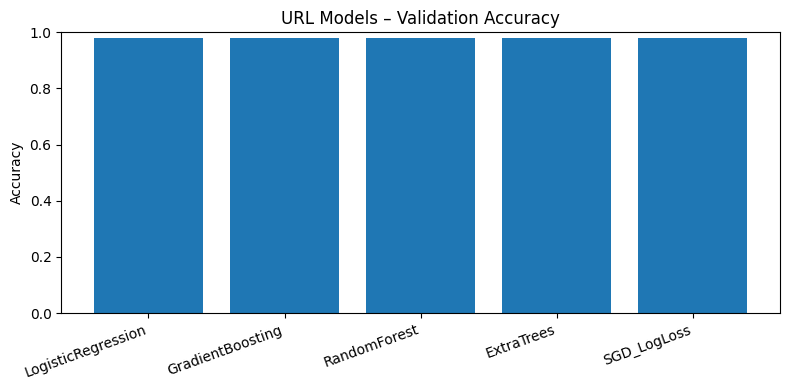

In [2]:
plt.figure(figsize=(8,4))
plt.bar(url_df["model"], url_df["val_accuracy"])
plt.xticks(rotation=20, ha="right")
plt.ylim(0,1)
plt.title("URL Models – Validation Accuracy")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("url_val_accuracy.png", dpi=150)
plt.show()


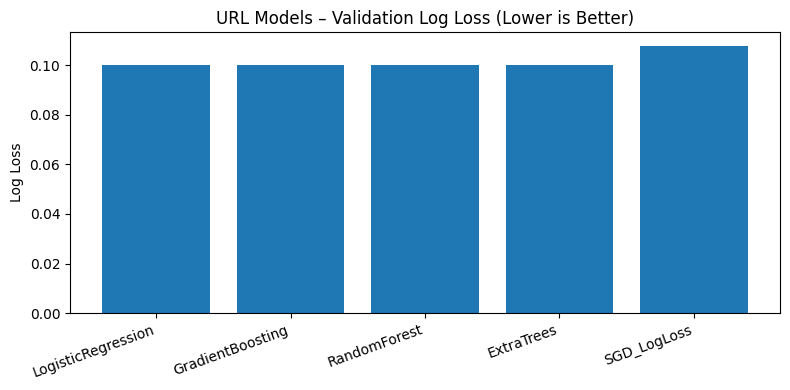

In [3]:
if url_df["val_logloss"].notna().any():
    plt.figure(figsize=(8,4))
    plt.bar(url_df["model"], url_df["val_logloss"].fillna(0))
    plt.xticks(rotation=20, ha="right")
    plt.title("URL Models – Validation Log Loss (Lower is Better)")
    plt.ylabel("Log Loss")
    plt.tight_layout()
    plt.savefig("url_val_logloss.png", dpi=150)
    plt.show()


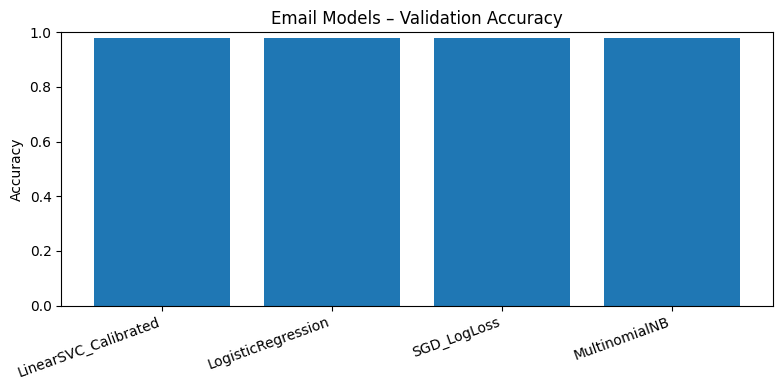

In [6]:
plt.figure(figsize=(8,4))
plt.bar(email_df["model"], email_df["val_accuracy"])
plt.xticks(rotation=20, ha="right")
plt.ylim(0,1)
plt.title("Email Models – Validation Accuracy")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("email_val_accuracy.png", dpi=150)
plt.show()


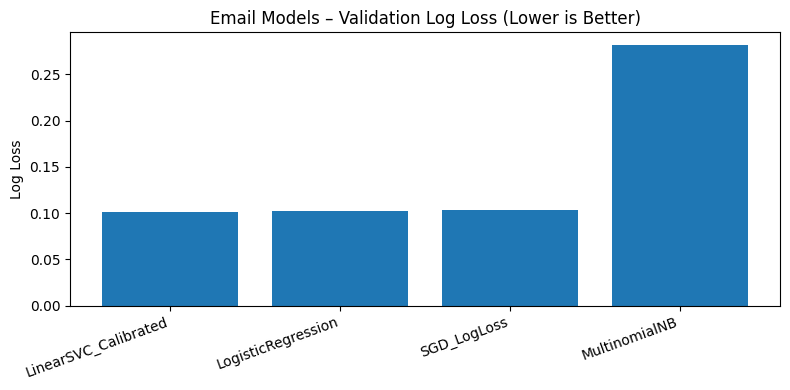

In [7]:
if email_df["val_logloss"].notna().any():
    plt.figure(figsize=(8,4))
    plt.bar(email_df["model"], email_df["val_logloss"].fillna(0))
    plt.xticks(rotation=20, ha="right")
    plt.title("Email Models – Validation Log Loss (Lower is Better)")
    plt.ylabel("Log Loss")
    plt.tight_layout()
    plt.savefig("email_val_logloss.png", dpi=150)
    plt.show()
